In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path("/scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting")
RESULTS_DIR = PROJECT_ROOT / "results" / "jeffy22"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22


In [4]:
self_csv = RESULTS_DIR / "self_supervised_results.csv"

if self_csv.exists():
    df_self = pd.read_csv(self_csv)
    print("Self-Supervised Results:")
    print(df_self[['experiment_name', 'mse', 'mae', 'pretrain_epochs', 'finetune_epochs', 'pretrain_time_min', 'finetune_time_min']])
else:
    print("self_supervised_results.csv not found")
    df_self = pd.DataFrame()

Self-Supervised Results:
                experiment_name       mse       mae  pretrain_epochs  \
0  Self_Supervised_ETTh1_336_96  0.373746  0.396319              100   

   finetune_epochs  pretrain_time_min  finetune_time_min  
0               20          34.806314           3.712344  


In [5]:
# Find self-supervised loss files
self_loss_files = glob.glob(str(PROJECT_ROOT / "PatchTST/PatchTST_self_supervised/saved_models/etth1/masked_patchtst/based_model/*_losses.csv"))

loss_data = {}
for f in self_loss_files:
    df = pd.read_csv(f)
    fname = Path(f).name
    
    if 'pretrain100' in fname:
        name = 'Pre-training (100 epochs)'
    elif 'pretrain1' in fname:
        continue
    elif 'finetuned' in fname:
        name = 'Fine-tuning'
    else:
        continue
    
    loss_data[name] = df
    print(f"Loaded: {name} - {len(df)} epochs")

Loaded: Pre-training (100 epochs) - 100 epochs
Loaded: Fine-tuning - 20 epochs


In [6]:
if len(df_self) > 0:
    self_mse = df_self['mse'].iloc[0]
    self_mae = df_self['mae'].iloc[0]
    pretrain_time = df_self['pretrain_time_min'].iloc[0]
    finetune_time = df_self['finetune_time_min'].iloc[0]
    
    print("SELF-SUPERVISED PATCHTST RESULTS")
    print(f"Final MSE: {self_mse:.4f}")
    print(f"Final MAE: {self_mae:.4f}")
    print(f"Pre-training time: {pretrain_time:.1f} minutes")
    print(f"Fine-tuning time: {finetune_time:.1f} minutes")
    print(f"Total time: {pretrain_time + finetune_time:.1f} minutes")

SELF-SUPERVISED PATCHTST RESULTS
Final MSE: 0.3737
Final MAE: 0.3963
Pre-training time: 34.8 minutes
Fine-tuning time: 3.7 minutes
Total time: 38.5 minutes


In [7]:
if 'Pre-training (100 epochs)' in loss_data:
    df_pretrain = loss_data['Pre-training (100 epochs)']
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(df_pretrain['train_loss'], label='Training Loss', color='#3498db', linewidth=1.5)
    ax.plot(df_pretrain['valid_loss'], label='Validation Loss', color='#e74c3c', linewidth=1.5, linestyle='--')
    
    # Mark best epoch
    best_epoch = df_pretrain['valid_loss'].idxmin()
    best_loss = df_pretrain['valid_loss'].min()
    ax.scatter(best_epoch, best_loss, s=100, color='red', zorder=5, marker='o')
    ax.annotate(f'Best: {best_loss:.4f}', (best_epoch, best_loss), 
               xytext=(10, -10), textcoords='offset points', fontsize=10)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Self-Supervised Pre-training Loss Curves', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'self_pretrain_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {RESULTS_DIR / 'self_pretrain_loss_curves.png'}")

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_pretrain_loss_curves.png


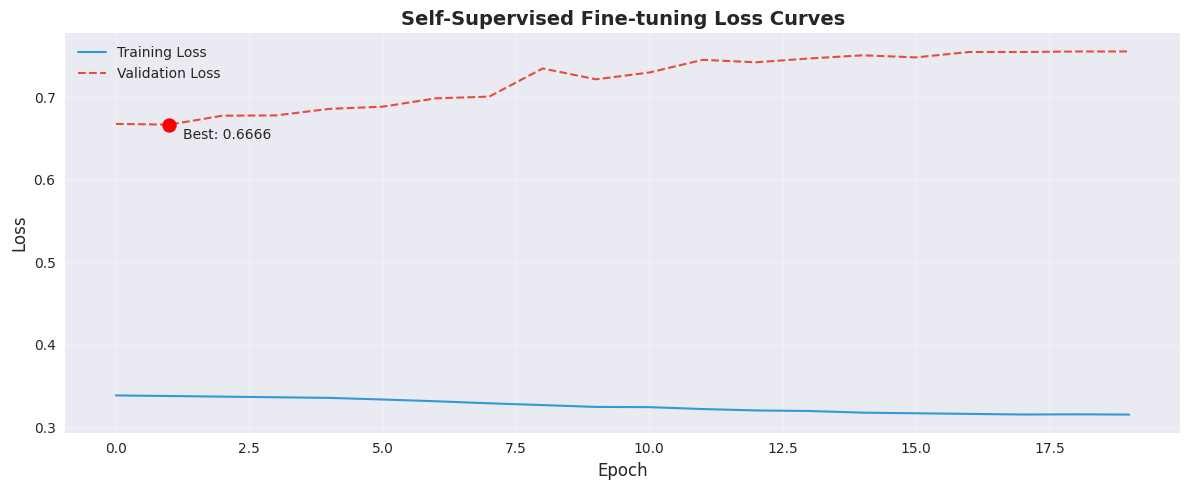

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_finetune_loss_curves.png


In [16]:
if 'Fine-tuning' in loss_data:
    df_finetune = loss_data['Fine-tuning']
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(df_finetune['train_loss'], label='Training Loss', color='#3498db', linewidth=1.5)
    ax.plot(df_finetune['valid_loss'], label='Validation Loss', color='#e74c3c', linewidth=1.5, linestyle='--')
    
    # Mark best epoch
    best_epoch = df_finetune['valid_loss'].idxmin()
    best_loss = df_finetune['valid_loss'].min()
    ax.scatter(best_epoch, best_loss, s=100, color='red', zorder=5, marker='o')
    ax.annotate(f'Best: {best_loss:.4f}', (best_epoch, best_loss), 
               xytext=(10, -10), textcoords='offset points', fontsize=10)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Self-Supervised Fine-tuning Loss Curves', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'self_finetune_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {RESULTS_DIR / 'self_finetune_loss_curves.png'}")

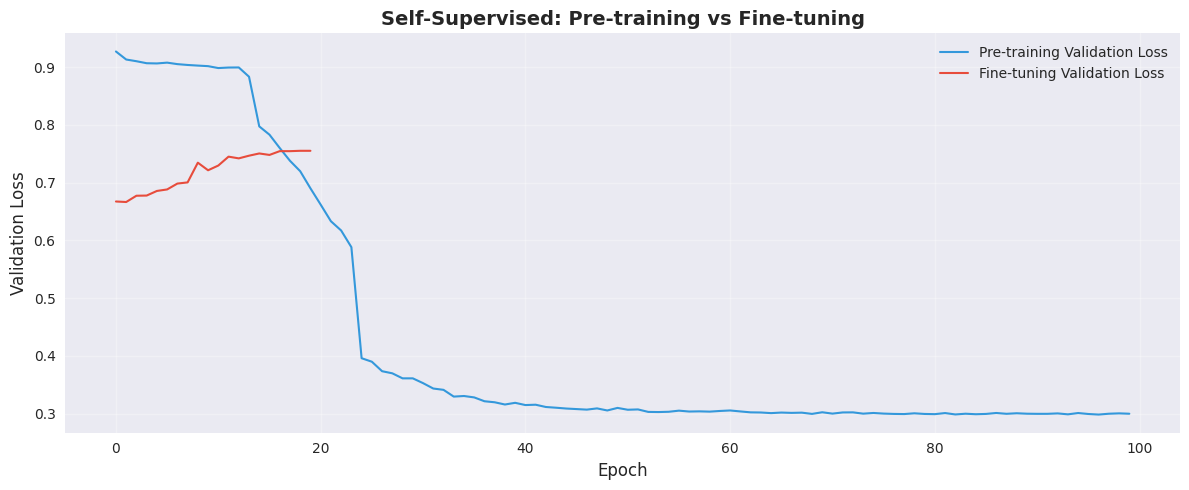

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_combined_loss_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

if 'Pre-training (100 epochs)' in loss_data:
    df_pretrain = loss_data['Pre-training (100 epochs)']
    ax.plot(df_pretrain['valid_loss'], label='Pre-training Validation Loss', color='#3498db', linewidth=1.5)

if 'Fine-tuning' in loss_data:
    df_finetune = loss_data['Fine-tuning']
    # Align epochs for fine-tuning
    ax.plot(range(len(df_finetune)), df_finetune['valid_loss'], 
            label='Fine-tuning Validation Loss', color='#e74c3c', linewidth=1.5)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Self-Supervised: Pre-training vs Fine-tuning', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'self_combined_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {RESULTS_DIR / 'self_combined_loss_curves.png'}")

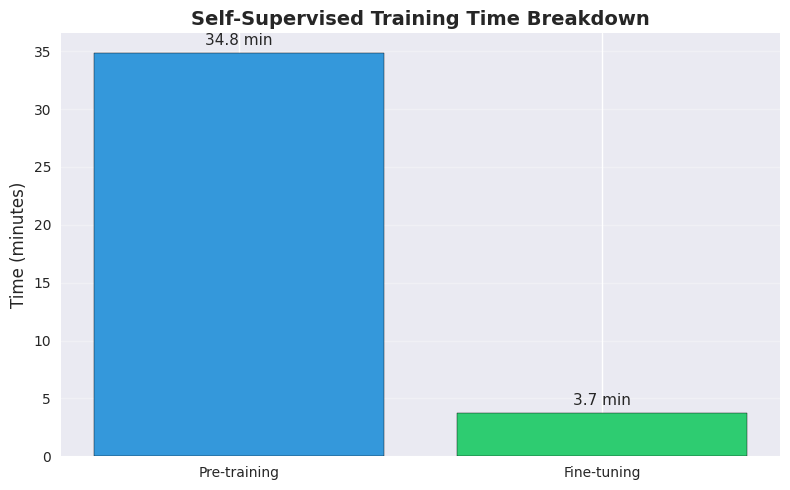

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_training_time.png


In [10]:
if len(df_self) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    stages = ['Pre-training', 'Fine-tuning']
    times = [df_self['pretrain_time_min'].iloc[0], df_self['finetune_time_min'].iloc[0]]
    colors = ['#3498db', '#2ecc71']
    
    bars = ax.bar(stages, times, color=colors, edgecolor='black')
    ax.set_ylabel('Time (minutes)', fontsize=12)
    ax.set_title('Self-Supervised Training Time Breakdown', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f} min', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'self_training_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {RESULTS_DIR / 'self_training_time.png'}")

In [11]:
if len(df_self) > 0:
    print("SELF-SUPERVISED HYPERPARAMETERS")
    print(f"\nPre-training:")
    print(f"  Context points: {df_self['seq_len'].iloc[0]}")
    print(f"  Patch length: {df_self['pretrain_patch_len'].iloc[0]}")
    print(f"  Stride: {df_self['pretrain_stride'].iloc[0]}")
    print(f"  Mask ratio: {df_self['mask_ratio'].iloc[0]}")
    print(f"  Epochs: {df_self['pretrain_epochs'].iloc[0]}")
    print(f"\nFine-tuning:")
    print(f"  Context points: {df_self['seq_len'].iloc[0]}")
    print(f"  Patch length: {df_self['finetune_patch_len'].iloc[0]}")
    print(f"  Stride: {df_self['finetune_stride'].iloc[0]}")
    print(f"  Epochs: {df_self['finetune_epochs'].iloc[0]}")
    print(f"\nHardware:")
    print(f"  GPU: {df_self['gpu_name'].iloc[0]}")
    print(f"  GPU Memory: {df_self['gpu_memory'].iloc[0]}")

SELF-SUPERVISED HYPERPARAMETERS

Pre-training:
  Context points: 336
  Patch length: 12
  Stride: 12
  Mask ratio: 0.4
  Epochs: 100

Fine-tuning:
  Context points: 336
  Patch length: 16
  Stride: 8
  Epochs: 20

Hardware:
  GPU: NVIDIA A100-SXM4-40GB
  GPU Memory: 40960 MiB


In [12]:
# Create summary CSV
if len(df_self) > 0:
    summary = {
        'Metric': ['Final MSE', 'Final MAE', 'Pre-training Time (min)', 'Fine-tuning Time (min)', 'Total Time (min)', 'GPU', 'Pre-training Epochs', 'Fine-tuning Epochs', 'Mask Ratio'],
        'Value': [
            f"{df_self['mse'].iloc[0]:.4f}",
            f"{df_self['mae'].iloc[0]:.4f}",
            f"{df_self['pretrain_time_min'].iloc[0]:.1f}",
            f"{df_self['finetune_time_min'].iloc[0]:.1f}",
            f"{df_self['total_time_min'].iloc[0]:.1f}",
            df_self['gpu_name'].iloc[0],
            df_self['pretrain_epochs'].iloc[0],
            df_self['finetune_epochs'].iloc[0],
            df_self['mask_ratio'].iloc[0]
        ]
    }
    
    df_summary = pd.DataFrame(summary)
    df_summary.to_csv(RESULTS_DIR / 'self_supervised_summary.csv', index=False)
    print(f"Saved to: {RESULTS_DIR / 'self_supervised_summary.csv'}")
    print("SELF-SUPERVISED VISUALIZATIONS COMPLETE!")
    print("\nGenerated files:")
    print(f"  {RESULTS_DIR / 'self_pretrain_loss_curves.png'}")
    print(f"  {RESULTS_DIR / 'self_finetune_loss_curves.png'}")
    print(f"  {RESULTS_DIR / 'self_combined_loss_curves.png'}")
    print(f"  {RESULTS_DIR / 'self_training_time.png'}")
    print(f"  {RESULTS_DIR / 'self_supervised_summary.csv'}")

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_supervised_summary.csv
SELF-SUPERVISED VISUALIZATIONS COMPLETE!

Generated files:
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_pretrain_loss_curves.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_finetune_loss_curves.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_combined_loss_curves.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_training_time.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/self_supervised_summary.csv
